In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

RANDOM_STATE = 42
IMAGE_SIZE = (32, 32)
NUM_CLASSES = 43
EXPECTED_TEST_IMAGES = 12630
BATCH_SIZE = 32

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATASET_DIR = PROJECT_ROOT / "dataset"
MODEL_PATH = PROJECT_ROOT / "models" / "traffic_sign_cnn.keras"
TEST_CSV = DATASET_DIR / "Test.csv"
TEST_DIR = DATASET_DIR / "Test"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CONFUSION_MATRIX_PATH = OUTPUT_DIR / "confusion_matrix.png"

for required_path in (MODEL_PATH, TEST_CSV, TEST_DIR):
    if not required_path.exists():
        raise FileNotFoundError(f"Required path was not found: {required_path.resolve()}")

print("Model:", MODEL_PATH.resolve())
print("Test labels:", TEST_CSV.resolve())
print("Test image directory:", TEST_DIR.resolve())

Model: D:\traffic-sign-recogonition\models\traffic_sign_cnn.keras
Test labels: D:\traffic-sign-recogonition\dataset\Test.csv
Test image directory: D:\traffic-sign-recogonition\dataset\Test


In [2]:
test_df = pd.read_csv(TEST_CSV)
required_columns = {"ClassId", "Path"}
missing_columns = required_columns - set(test_df.columns)
if missing_columns:
    raise ValueError(f"Test.csv is missing columns: {sorted(missing_columns)}")

if len(test_df) != EXPECTED_TEST_IMAGES:
    raise ValueError(f"Expected {EXPECTED_TEST_IMAGES} test images, found {len(test_df)}")

test_df["ClassId"] = test_df["ClassId"].astype(int)
test_df["ImagePath"] = test_df["Path"].map(lambda relative_path: DATASET_DIR / relative_path)
missing_images = test_df.loc[~test_df["ImagePath"].map(Path.exists)]
if not missing_images.empty:
    raise FileNotFoundError(f"Missing test images: {len(missing_images)}")

X_test = np.empty((len(test_df), IMAGE_SIZE[1], IMAGE_SIZE[0], 3), dtype=np.float32)
y_test = test_df["ClassId"].to_numpy(dtype=np.int64)

for index, image_path in enumerate(test_df["ImagePath"]):
    with Image.open(image_path) as image:
        image = image.convert("RGB")
        image = image.resize(IMAGE_SIZE, Image.Resampling.LANCZOS)
        image_array = np.asarray(image, dtype=np.float32) / 255.0

    if image_array.shape != (IMAGE_SIZE[1], IMAGE_SIZE[0], 3):
        raise ValueError(f"Unexpected image shape for {image_path}: {image_array.shape}")
    X_test[index] = image_array

assert X_test.shape == (EXPECTED_TEST_IMAGES, 32, 32, 3)
assert y_test.shape == (EXPECTED_TEST_IMAGES,)
assert X_test.min() >= 0.0 and X_test.max() <= 1.0
assert set(np.unique(y_test)) == set(range(NUM_CLASSES))

print("Loaded test images:", X_test.shape)
print("Loaded test labels:", y_test.shape)
print("Pixel range:", (float(X_test.min()), float(X_test.max())))
print("Augmentation applied: False")

Loaded test images: (12630, 32, 32, 3)
Loaded test labels: (12630,)
Pixel range: (0.0, 1.0)
Augmentation applied: False


In [3]:
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

test_metrics = model.evaluate(
    X_test,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True,
)

prediction_probabilities = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(prediction_probabilities, axis=1)
prediction_confidence = np.max(prediction_probabilities, axis=1)

test_accuracy = float(test_metrics["accuracy"])
test_loss = float(test_metrics["loss"])
test_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
test_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
test_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")
print(f"Macro precision: {test_precision:.4%}")
print(f"Macro recall: {test_recall:.4%}")
print(f"Macro F1-score: {test_f1:.4%}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,083,203 (4.13 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 722,136 (2.75 MB)

395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9515 - loss: 0.2129
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Test loss: 0.2129
Test accuracy: 95.1465%
Macro precision: 92.8425%
Macro recall: 92.9763%
Macro F1-score: 92.4892%


In [4]:
class_labels = list(range(NUM_CLASSES))
print("Classification report")
print(classification_report(
    y_test,
    y_pred,
    labels=class_labels,
    target_names=[f"Class {class_id}" for class_id in class_labels],
    digits=4,
    zero_division=0,
))

Classification report
              precision    recall  f1-score   support

     Class 0     0.9833    0.9833    0.9833        60
     Class 1     0.9848    0.9875    0.9861       720
     Class 2     0.9409    0.9973    0.9683       750
     Class 3     0.8934    0.9689    0.9296       450
     Class 4     0.9969    0.9636    0.9800       660
     Class 5     0.8969    0.8841    0.8905       630
     Class 6     0.9408    0.9533    0.9470       150
     Class 7     0.9950    0.8800    0.9340       450
     Class 8     0.9468    0.9889    0.9674       450
     Class 9     0.9938    0.9979    0.9958       480
    Class 10     0.9969    0.9894    0.9932       660
    Class 11     0.9506    0.8714    0.9093       420
    Class 12     1.0000    0.9449    0.9717       690
    Class 13     0.9917    0.9931    0.9924       720
    Class 14     1.0000    0.9889    0.9944       270
    Class 15     0.9766    0.9952    0.9858       210
    Class 16     1.0000    1.0000    1.0000       150
    C

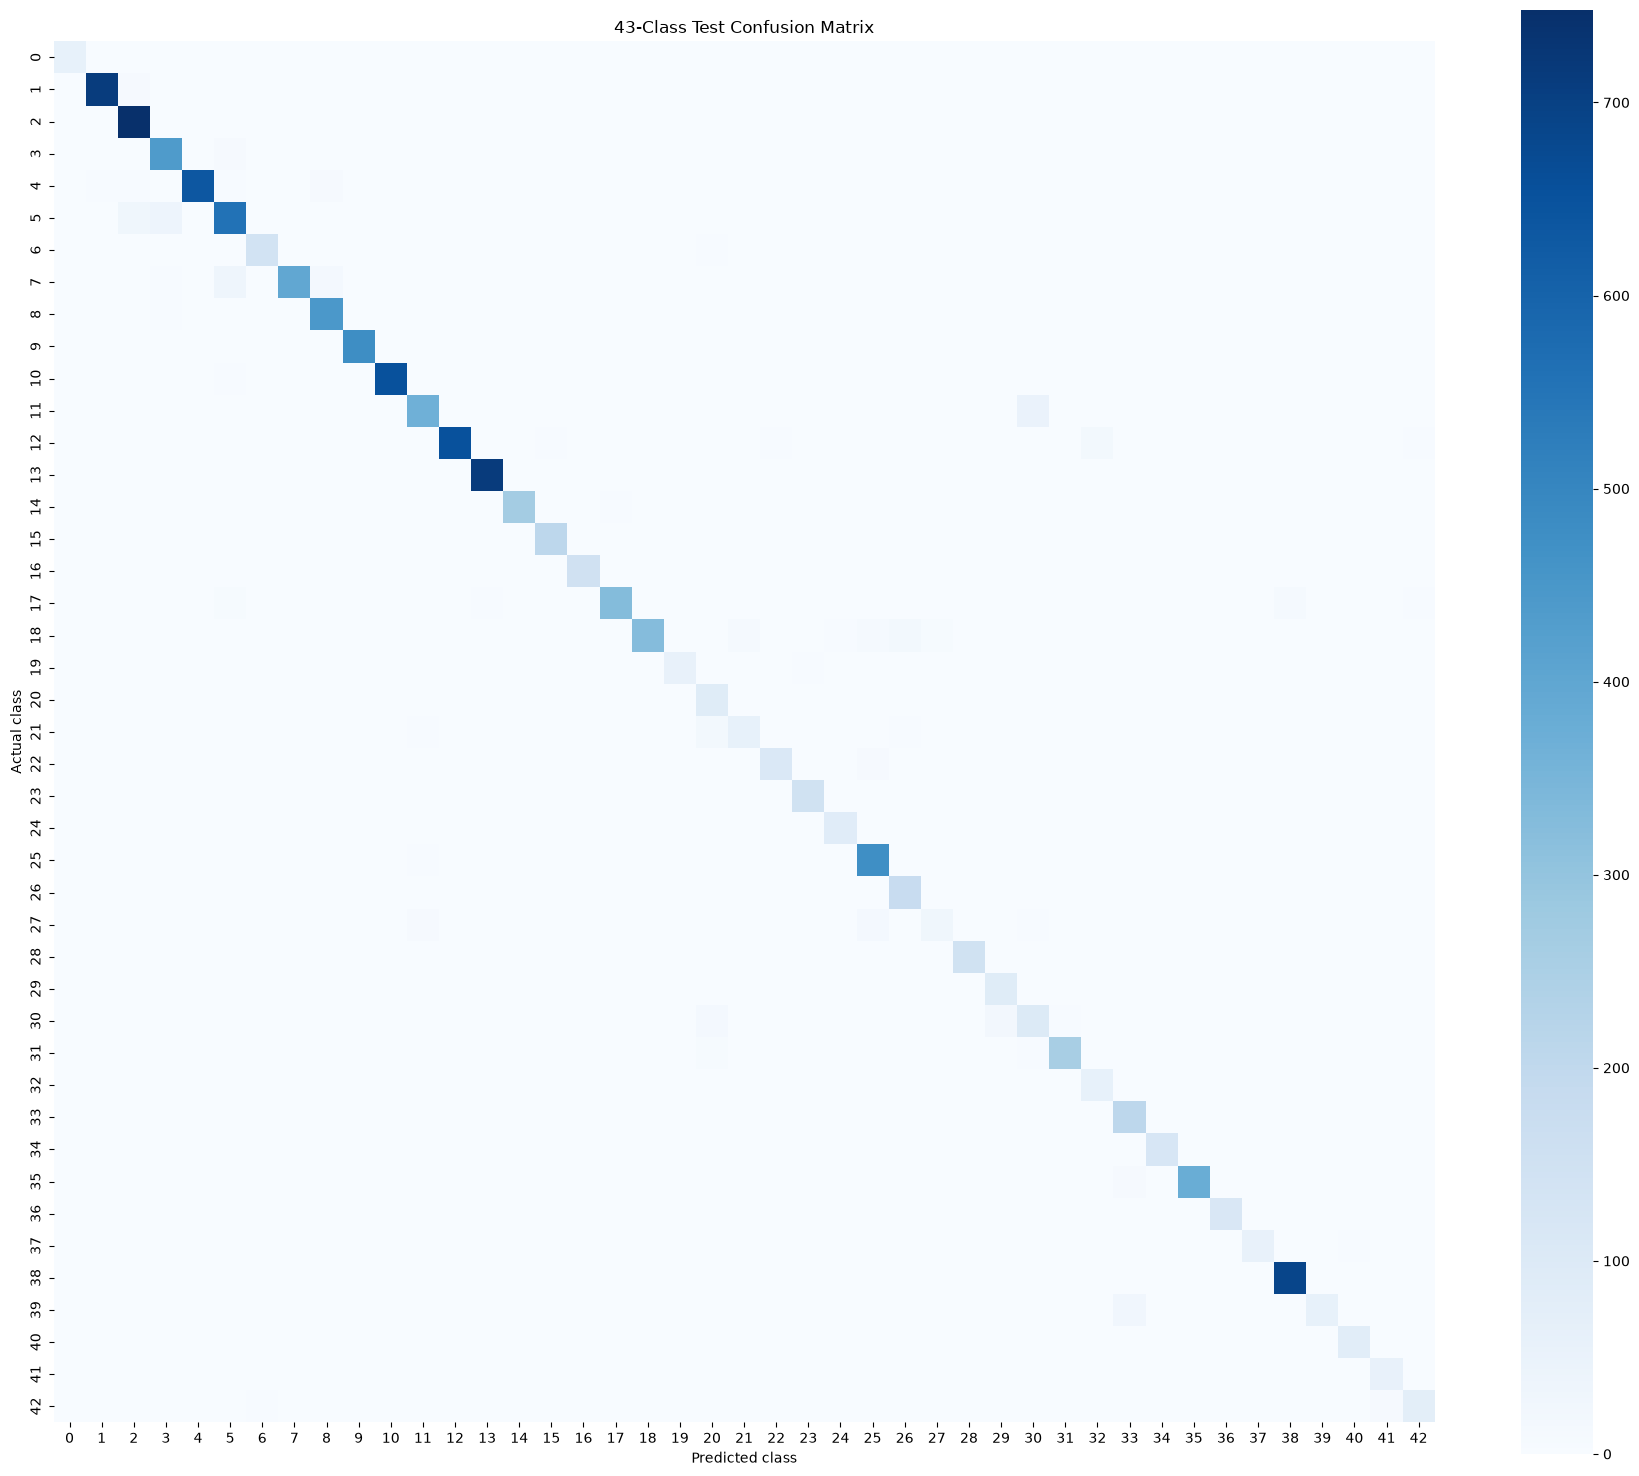

Saved confusion matrix to: D:\traffic-sign-recogonition\outputs\confusion_matrix.png


In [5]:
confusion = confusion_matrix(y_test, y_pred, labels=class_labels)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

figure, axis = plt.subplots(figsize=(18, 15))
sns.heatmap(
    confusion,
    cmap="Blues",
    square=True,
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=True,
    ax=axis,
)
axis.set_title("43-Class Test Confusion Matrix")
axis.set_xlabel("Predicted class")
axis.set_ylabel("Actual class")
figure.tight_layout()
figure.savefig(CONFUSION_MATRIX_PATH, dpi=200)
plt.show()
print(f"Saved confusion matrix to: {CONFUSION_MATRIX_PATH.resolve()}")

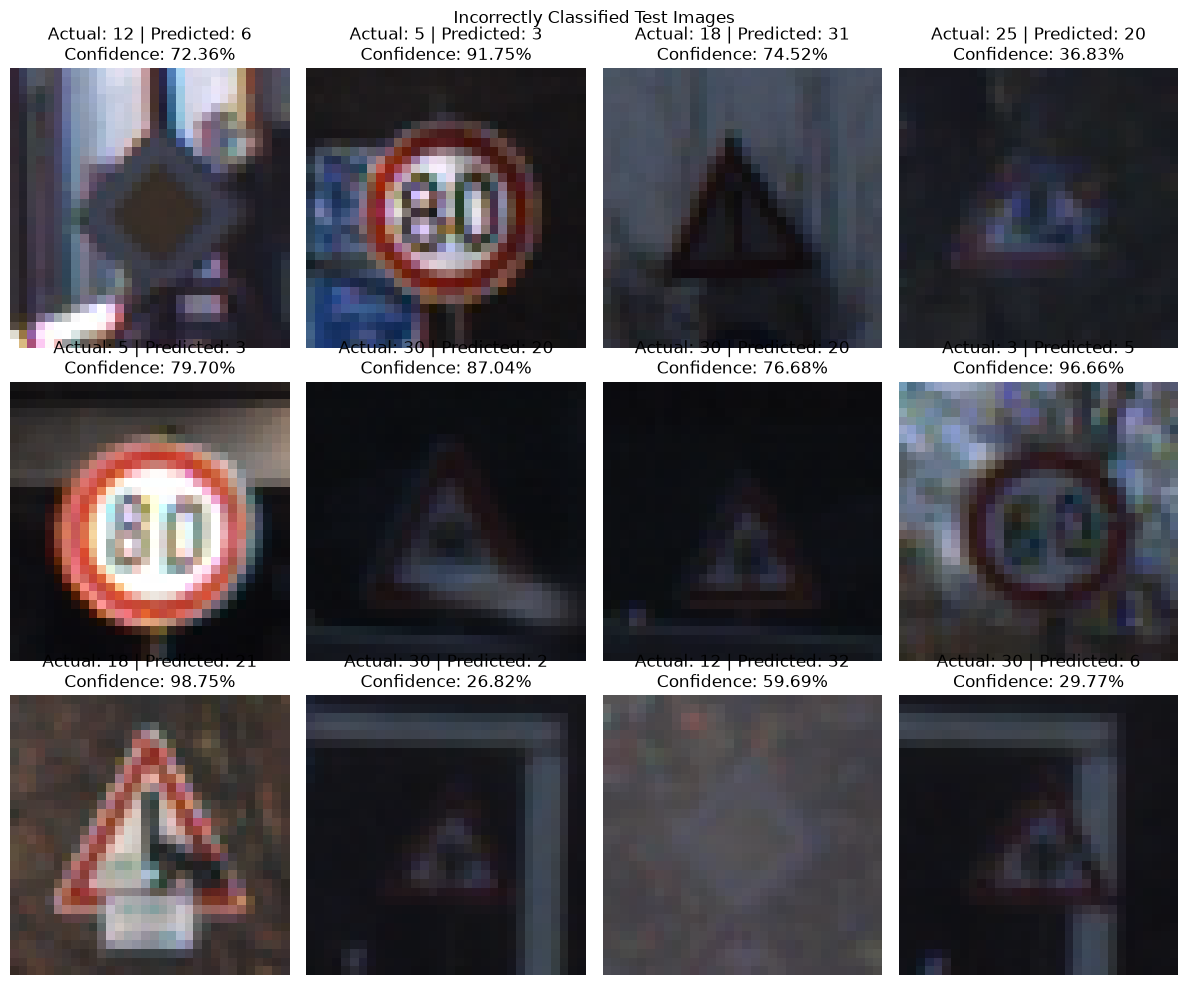

Incorrect predictions: 613
Displayed incorrect examples: 12


In [6]:
incorrect_indices = np.flatnonzero(y_test != y_pred)
display_count = min(12, len(incorrect_indices))

if display_count == 0:
    print("No incorrectly classified test images were found.")
else:
    figure, axes = plt.subplots(3, 4, figsize=(12, 10))
    axes = axes.ravel()

    for axis in axes:
        axis.axis("off")

    for axis, test_index in zip(axes, incorrect_indices[:display_count]):
        axis.imshow(X_test[test_index])
        axis.set_title(
            f"Actual: {y_test[test_index]} | Predicted: {y_pred[test_index]}\n"
            f"Confidence: {prediction_confidence[test_index]:.2%}"
        )
        axis.axis("off")

    figure.suptitle("Incorrectly Classified Test Images")
    figure.tight_layout()
    plt.show()

print("Incorrect predictions:", len(incorrect_indices))
print("Displayed incorrect examples:", display_count)

In [8]:
training_accuracy = 0.9572
validation_accuracy = 0.9895

print("Accuracy comparison")
print(f"Training accuracy: {training_accuracy:.4%}")
print(f"Validation accuracy: {validation_accuracy:.4%}")
print(f"Test accuracy: {test_accuracy:.4%}")
print("Test data was evaluated without augmentation and was not used for training or tuning.")

Accuracy comparison
Training accuracy: 95.7200%
Validation accuracy: 98.9500%
Test accuracy: 95.1465%
Test data was evaluated without augmentation and was not used for training or tuning.
